In [2]:
import sys
import json
import pathlib
import warnings
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore", category=FutureWarning)

root = pathlib.Path("../src").resolve()
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from mltools          import MLConfig
from mltools.shared.logging import setup_logging
from loguru import logger

config = MLConfig.from_yaml("../configs/ml_config.yaml")
setup_logging(
    log_level  = config.project.log_level,
    log_dir    = "../logs",
    experiment = config.project.name,
)

TARGET    = config.data.target_column
ID_COLS   = config.data.id_columns
DATE_COLS = config.data.date_columns

X_train = pd.read_parquet("../data/interim/X_train_clean.parquet")
X_val   = pd.read_parquet("../data/interim/X_val_clean.parquet")
X_test  = pd.read_parquet("../data/interim/X_test_clean.parquet")
y_train = pd.read_parquet("../data/interim/y_train_clean.parquet").squeeze()
y_val   = pd.read_parquet("../data/interim/y_val_clean.parquet").squeeze()
y_test  = pd.read_parquet("../data/interim/y_test_clean.parquet").squeeze()

with open("../models/preprocessing/preprocessing_meta.json") as f:
    prep_meta = json.load(f)

binary_indicator_cols = prep_meta["binary_indicator_cols"]


d:\ml_pipeline\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Feature Egineering

In [ ]:
from mltools.preprocessing.engineer import ExpertFeatureEngineer

fe = ExpertFeatureEngineer(
    add_ratios=True,
    ratio_pairs=[
        ("qty_and_url", "qty_equal_url")
    ],

    add_interaction=True,
    interaction_pairs=[
        ("qty_and_url", "qty_equal_url") 
    ],
    
    add_text_features=False,             
    add_bins=True,
    bin_cols=["length_url", "time_response"], 
    n_bins=5,
    bin_strategy="quantile"
)

fe.fit(X_train)

X_train = fe.transform(X_train)
X_val   = fe.transform(X_val)
X_test  = fe.transform(X_test)

new_bin_cols = [c for c in X_train.columns if c.endswith("_bin")]
new_ratio_cols = [c for c in X_train.columns
                  if "_div_" in c or "_pct_" in c or "_x_" in c]

print(f"Bentuk akhir fitur X_train: {X_train.shape}")


04:21:06 | INFO     | mltools.preprocessing.engineer:103 | FeatureEngineer fitted


04:21:06 | INFO     | mltools.preprocessing.engineer:174 | Feature engineering selesai. Shape: (61045, 142)
04:21:06 | INFO     | mltools.preprocessing.engineer:174 | Feature engineering selesai. Shape: (13082, 142)
04:21:06 | INFO     | mltools.preprocessing.engineer:174 | Feature engineering selesai. Shape: (13082, 142)
Bentuk akhir fitur X_train: (61045, 142)


Feature Scaling

04:23:11 | INFO     | mltools.preprocessing.scaler:69 | Fitting scaler (robust) pada 45 kolom
04:23:11 | INFO     | mltools.preprocessing.scaler:81 | Kolom yang akan ditransformasi (yeojohnson): ['qty_slash_url', 'length_url', 'qty_hyphen_directory', 'qty_hyphen_file', 'qty_equal_file', 'qty_at_file', 'qty_and_file', 'qty_plus_file', 'time_response', 'domain_spf', 'qty_nameservers', 'ttl_hostname', 'qty_redirects']
04:23:12 | SUCCESS  | mltools.preprocessing.scaler:151 | ScalerTransformer fitted!
                       column  skewness  abs_skewness  will_transform severity
41            qty_nameservers    1.4407        1.4407            True    MED ~
44              qty_redirects    1.2982        1.2982            True    MED ~
37                 domain_spf    1.2558        1.2558            True    MED ~
23            qty_hyphen_file    1.1925        1.1925            True    MED ~
2                  length_url    1.1590        1.1590            True    MED ~
25             qty_equal

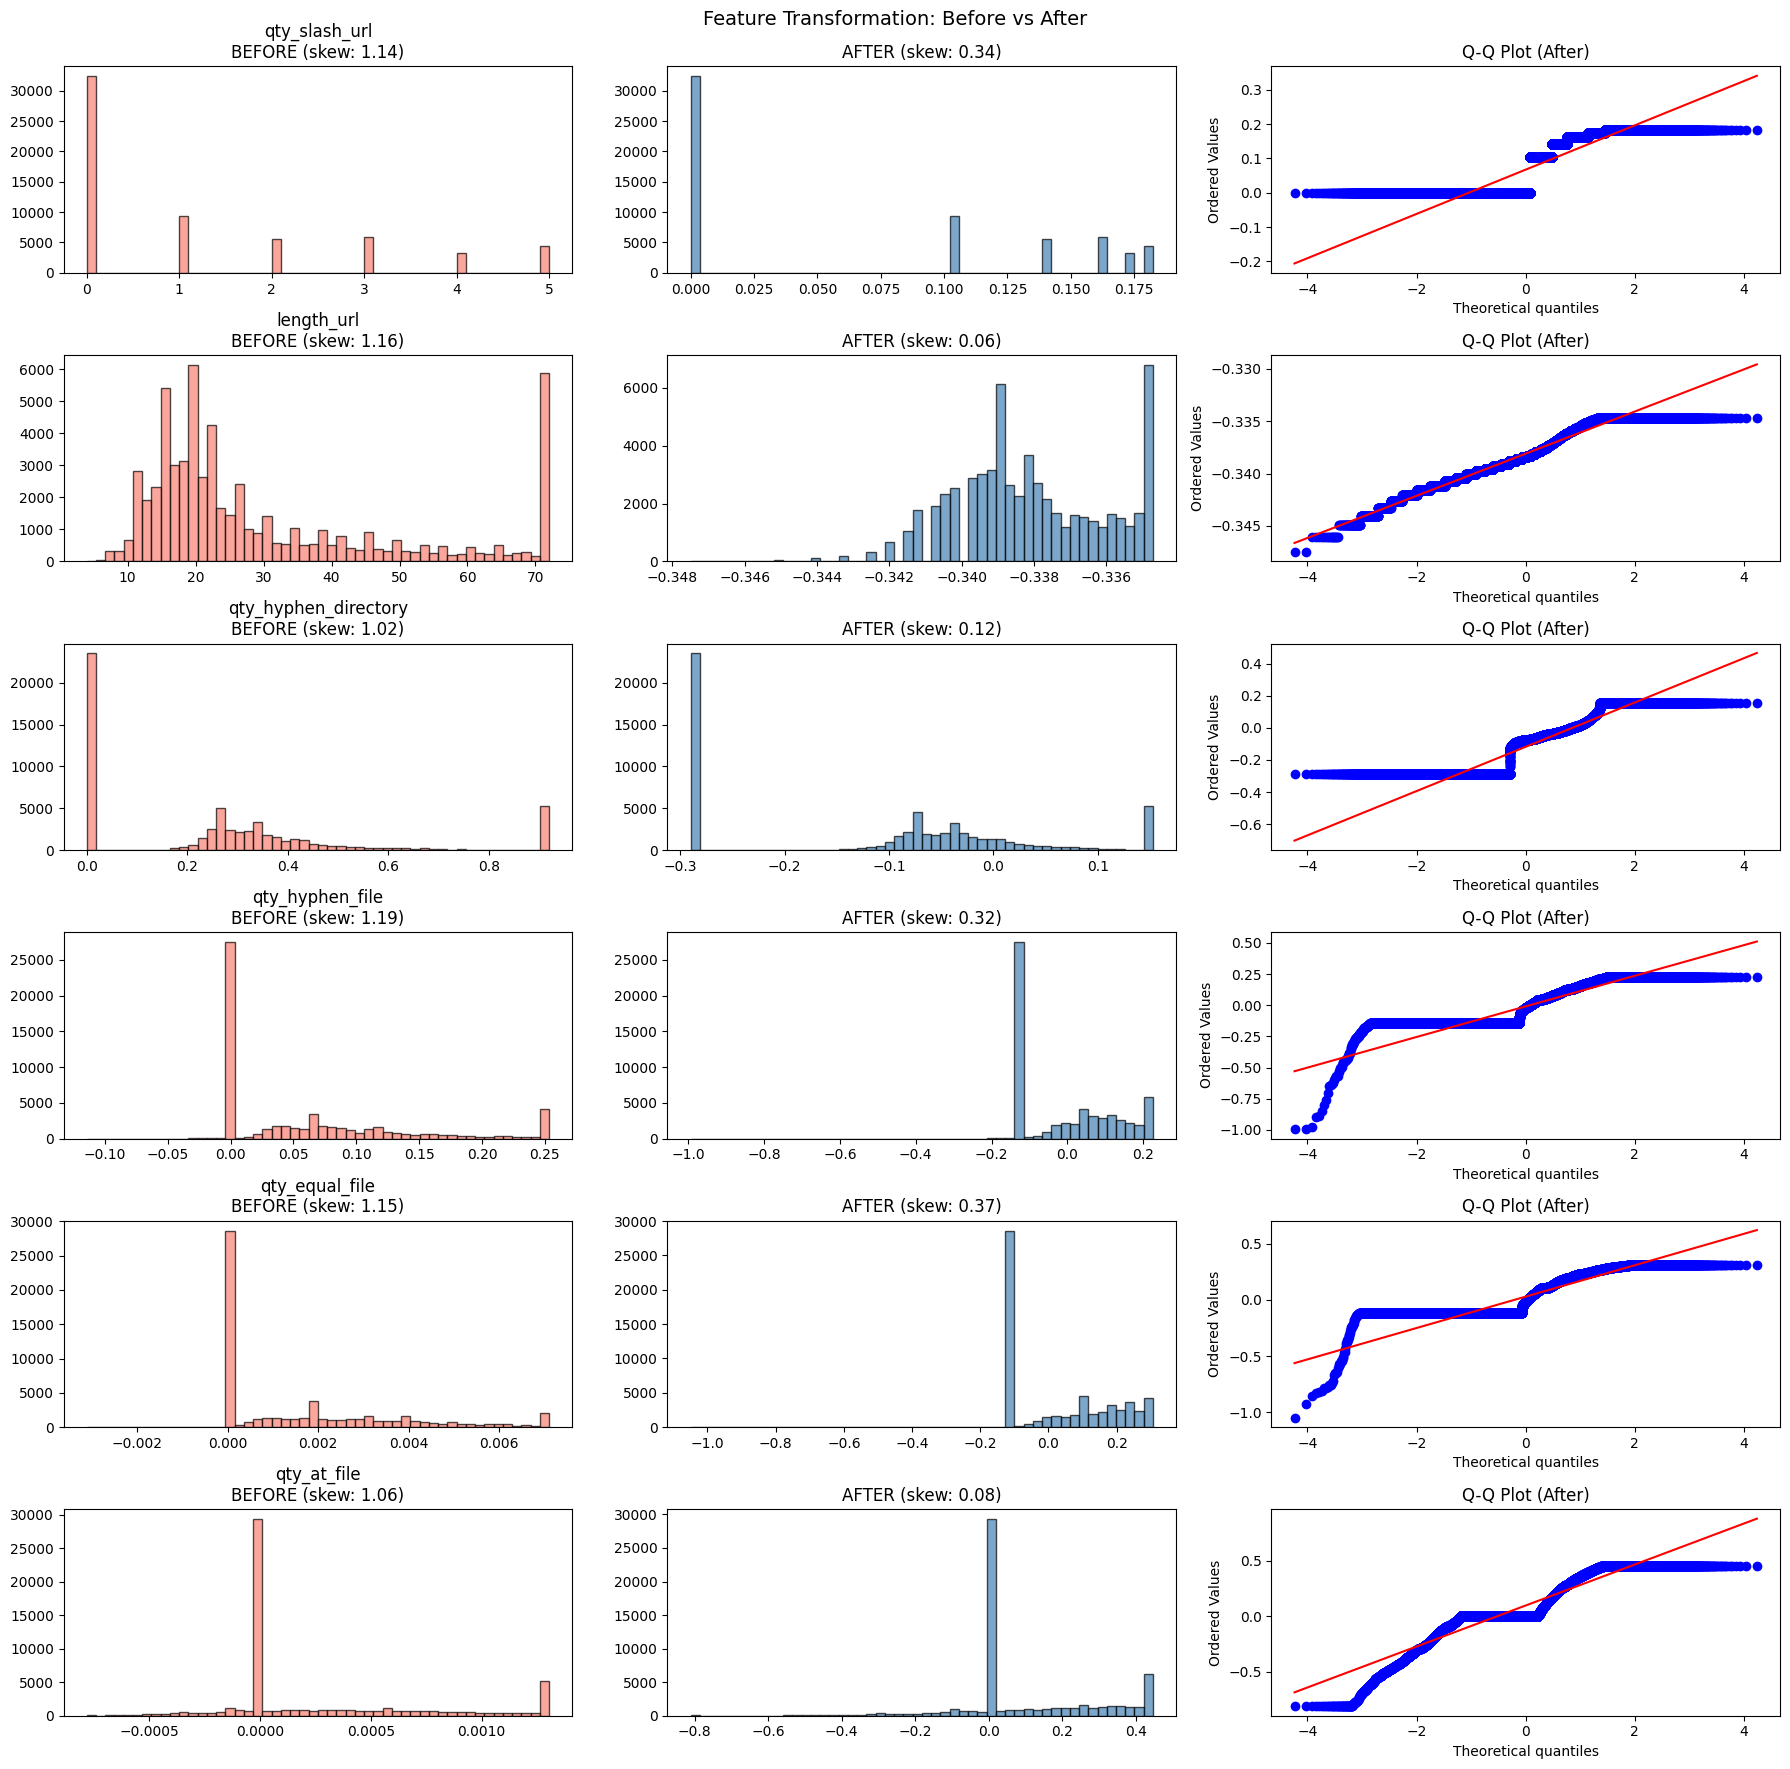

In [4]:
from mltools.preprocessing.scaler import ExpertScalerTransformer, plot_transformation_effect

all_num_cols = X_train.select_dtypes(include="number").columns.tolist()

exclude_scaling = list(set(
    binary_indicator_cols
    +
    [c for c in X_train.columns if c.endswith("_bin")]
    +
    [
        c for c in all_num_cols
        if set(X_train[c].dropna().unique()).issubset({0, 1})
        and X_train[c].nunique() <= 2
    ]
))


scaler = ExpertScalerTransformer(
    scaler        = "robust",
    auto_transform= True,
    exclude_cols  = exclude_scaling
)

scaler.fit(X_train)

report_skew = scaler.get_skewness_report(X_train)
print(report_skew)

X_train_before = X_train.copy()

X_train = scaler.transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

plot_transformation_effect(
    X_train_before, X_train,
    columns=scaler.transform_cols_[:6]
)

Feature Selection

04:24:32 | INFO     | mltools.preprocessing.selector:99 | Feature selection mulai | Fitur awal: 142
04:24:32 | INFO     | mltools.preprocessing.selector:108 | [L1] Quasi-constant: 55 dropped | Sisa: 87
04:24:33 | INFO     | mltools.preprocessing.selector:129 | [L2] High-corr: 38 dropped | Sisa: 49
04:26:24 | INFO     | mltools.preprocessing.selector:162 | [L3] Kept top 24 | Dropped: 25
04:26:24 | SUCCESS  | mltools.preprocessing.selector:170 | SELESAI: 142 => 24 fitur
04:26:24 | INFO     | mltools.preprocessing.selector:279 | =======================================================
04:26:24 | INFO     | mltools.preprocessing.selector:282 |   Layer 1 dropped: 55
04:26:24 | INFO     | mltools.preprocessing.selector:282 |   Layer 2 dropped: 38
04:26:24 | INFO     | mltools.preprocessing.selector:282 |   Layer 3 dropped: 25
04:26:24 | INFO     | mltools.preprocessing.selector:283 |   Final features: 24
04:26:24 | INFO     | mltools.preprocessing.selector:284 | ==============================

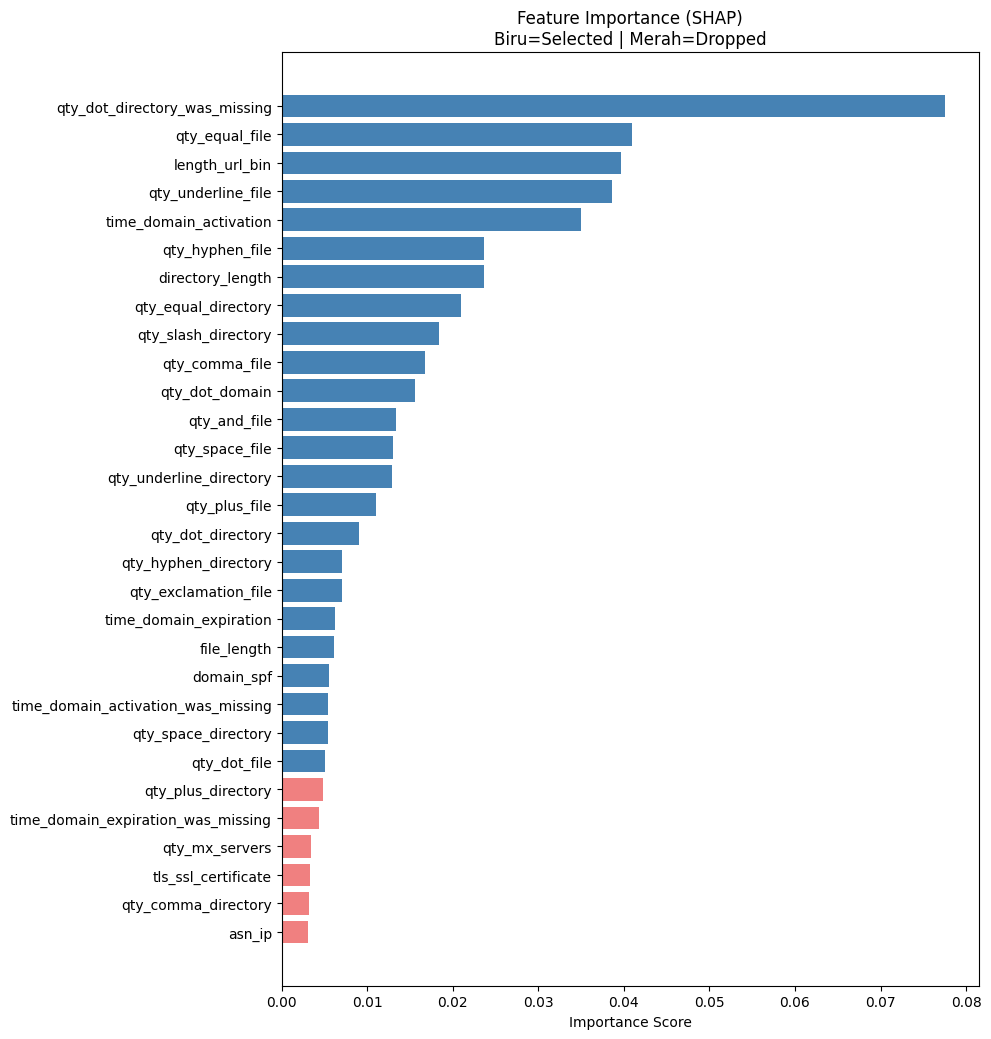

04:26:25 | INFO     | __main__:14 | Fitur setelah seleksi: 24


In [5]:
from mltools.preprocessing.selector import ExpertFeatureSelector, compute_permutation_importance

selector = ExpertFeatureSelector()

selector.fit(X_train, y_train)

selector.get_selection_report()
selector.plot_importance(top_n=30)

X_train = selector.transform(X_train)
X_val   = selector.transform(X_val)
X_test  = selector.transform(X_test)

logger.info(f"Fitur setelah seleksi: {len(selector.selected_features_)}")


Export ke folder Processed

In [6]:
import joblib
import json
from pathlib import Path

X_train.to_parquet("../data/processed/X_train.parquet", index=False)
X_val.to_parquet(  "../data/processed/X_val.parquet",   index=False)
X_test.to_parquet( "../data/processed/X_test.parquet",  index=False)

y_train.to_frame().to_parquet("../data/processed/y_train.parquet", index=False)
y_val.to_frame().to_parquet(  "../data/processed/y_val.parquet",   index=False)
y_test.to_frame().to_parquet( "../data/processed/y_test.parquet",  index=False)

logger.success("Data processed tersimpan ke data/processed/*.parquet")


joblib.dump(fe,       "../models/preprocessing/feature_engineer.joblib", compress=3)
joblib.dump(scaler,   "../models/preprocessing/scaler.joblib",           compress=3)
joblib.dump(selector, "../models/preprocessing/selector.joblib",         compress=3)

logger.success("Fitted components tersimpan ke models/preprocessing/*.joblib")

feature_meta = {
    "feature_names" : X_train.columns.tolist(),
    "n_features"    : len(X_train.columns),
    "target"        : TARGET,
    "task"          : config.modeling.task,
    "shapes": {
        "X_train": list(X_train.shape),
        "X_val"  : list(X_val.shape),
        "X_test" : list(X_test.shape),
    },
    "pipeline_steps": [
        "missing_handler",
        "outlier_handler",
        "feature_engineer",
        "scaler",
        "selector",
    ],
}

with open("../models/preprocessing/feature_names.json", "w") as f:
    json.dump(feature_meta, f, indent=2)

print("\n" + "="*55)
print("  FEATURE ENGINEERING SELESAI")
print("="*55)
print(f"  Fitur awal (dari nb02) : {X_train_before.shape[1]}")
print(f"  Fitur setelah FE       : {X_train_before.shape[1] + len(new_bin_cols) + len(new_ratio_cols)}")
print(f"  Fitur final (selected) : {len(selector.selected_features_)}")
print(f"\n  Selection summary:")
for k, v in selector.selection_log_.items():
    print(f"    {k:<25}: {len(v)} dropped")
print(f"\n  Files saved:")
for p in sorted(Path("../data/processed").glob("*.parquet")):
    size = p.stat().st_size / 1e6
    print(f"    data/processed/{p.name} ({size:.1f} MB)")
for p in sorted(Path("../models/preprocessing").glob("*.joblib")):
    size = p.stat().st_size / 1e3
    print(f"    models/preprocessing/{p.name} ({size:.0f} KB)")
print("="*55)

04:27:42 | SUCCESS  | __main__:13 | Data processed tersimpan ke data/processed/*.parquet
04:27:42 | SUCCESS  | __main__:20 | Fitted components tersimpan ke models/preprocessing/*.joblib

  FEATURE ENGINEERING SELESAI
  Fitur awal (dari nb02) : 142
  Fitur setelah FE       : 147
  Fitur final (selected) : 24

  Selection summary:
    layer1_dropped           : 55 dropped
    layer2_dropped           : 38 dropped
    layer3_dropped           : 25 dropped

  Files saved:
    data/processed/X_test.parquet (1.4 MB)
    data/processed/X_train.parquet (6.6 MB)
    data/processed/X_val.parquet (1.4 MB)
    data/processed/y_test.parquet (0.0 MB)
    data/processed/y_train.parquet (0.0 MB)
    data/processed/y_val.parquet (0.0 MB)
    models/preprocessing/feature_engineer.joblib (1 KB)
    models/preprocessing/missing_handler.joblib (8358 KB)
    models/preprocessing/outlier_handler.joblib (5 KB)
    models/preprocessing/scaler.joblib (2 KB)
    models/preprocessing/selector.joblib (3 KB)
